# 1. Импорт библиотек

In [2]:
import os
import random
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

# Автоматический выбор лучшего доступного ускорителя
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ Вычисления на NVIDIA GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✅ Вычисления на Apple Silicon GPU (MPS)")
else:
    device = torch.device("cpu")
    print("⚙️ Вычисления на CPU")

print("✅ Все библиотеки успешно импортированы!")

⚙️ Вычисления на CPU
✅ Все библиотеки успешно импортированы!


# 2. Функция патчинга

In [31]:
def slice_image_to_patches(
    image_or_path, 
    patch_size=512, 
    overlap_ratio=0.2,
    save_to_disk=False,         # False = только в RAM, True = записать на диск
    output_folder="patches_dump"
):
    """
    Универсальная функция нарезки снимка на перекрывающиеся патчи.
    """
    if isinstance(image_or_path, str):
        img = tiff.imread(image_or_path).astype(np.float32)
        base_name = os.path.splitext(os.path.basename(image_or_path))[0]
    else:
        img = image_or_path.astype(np.float32)
        base_name = "image"

    h, w = img.shape
    stride = int(patch_size * (1.0 - overlap_ratio))

    # Сетка координат с защитой от вылета за границы
    y_steps = list(range(0, h - patch_size + 1, stride))
    if y_steps[-1] != h - patch_size:
        y_steps.append(h - patch_size)

    x_steps = list(range(0, w - patch_size + 1, stride))
    if x_steps[-1] != w - patch_size:
        x_steps.append(w - patch_size)

    patches_list = []
    coords_list = []

    if save_to_disk:
        os.makedirs(output_folder, exist_ok=True)

    patch_idx = 0
    for y in y_steps:
        for x in x_steps:
            patch = img[y:y+patch_size, x:x+patch_size]
            patches_list.append(patch)
            coords_list.append((y, x))

            if save_to_disk:
                filename = f"{base_name}_p{patch_idx:03d}_y{y}_x{x}.tif"
                tiff.imwrite(os.path.join(output_folder, filename), patch)
                patch_idx += 1

    patches_array = np.array(patches_list)
    return patches_array, coords_list, (h, w)

print("✅ Функция slice_image_to_patches готова к работе!")

✅ Функция slice_image_to_patches готова к работе!


# 3. Запуск нарезки БЕЗ сохранения на диск

In [32]:
# ==============================================================================
# ⚙️ ГЛАВНЫЙ БЛОК НАСТРОЕК
# ==============================================================================
CURRENT_PATCH_SIZE = 512   # Размер патча: 512 или 256
CURRENT_OVERLAP    = 0.2   # Наложение
NUM_IMAGES = 10          

# Пути к папкам со снимками:
NOISY_DIR = "filestore/filestorage/V_beton30_angle05"
CLEAN_DIR = "filestore/filestorage/V_beton30_angle005"
# ==============================================================================

class CTLazyDataset(Dataset):
    """
    Универсальный датасет с ленивой загрузкой:
    - Хранит координаты в RAM (~15 МБ)
    - Считывает с диска только то, что нужно для текущего батча
    """
    def __init__(self, noisy_dir, clean_dir, patch_size=512, overlap_ratio=0.2, num_images=None):
        self.patch_size = patch_size
        
        # 1. Поиск сопоставленных пар файлов
        noisy_files = sorted([f for f in os.listdir(noisy_dir) if f.lower().endswith(('.tif', '.tiff'))])
        clean_files = sorted([f for f in os.listdir(clean_dir) if f.lower().endswith(('.tif', '.tiff'))])
        common = sorted(list(set(noisy_files) & set(clean_files)))
        
        assert len(common) > 0, "Не найдено парных файлов в папках!"
        
        if num_images is not None:
            self.common_names = common[:num_images]
            print(f"📁 Режим: ТЕСТОВЫЙ. Взято {len(self.common_names)} из {len(common)} пар снимков.")
        else:
            self.common_names = common
            print(f"📁 Режим: ПОЛНЫЙ ДАТАСЕТ. Загружаются ВСЕ {len(self.common_names)} пар снимков!")

        self.noisy_paths = [os.path.join(noisy_dir, f) for f in self.common_names]
        self.clean_paths = [os.path.join(clean_dir, f) for f in self.common_names]

        # 2. Определение размера снимка
        sample_img = tiff.imread(self.noisy_paths[0])
        h, w = sample_img.shape
        del sample_img

        # 3. Расчет сетки
        stride = int(patch_size * (1.0 - overlap_ratio))
        y_steps = list(range(0, h - patch_size + 1, stride))
        if y_steps[-1] != h - patch_size: y_steps.append(h - patch_size)
        x_steps = list(range(0, w - patch_size + 1, stride))
        if x_steps[-1] != w - patch_size: x_steps.append(w - patch_size)

        # 4. Формирование карты индексов (легковесные координаты в RAM)
        self.patch_index = []
        for img_idx in range(len(self.common_names)):
            for y in y_steps:
                for x in x_steps:
                    self.patch_index.append((img_idx, y, x))

        print(f"🎉 Сформирован индекс: {len(self.patch_index)} патчей {patch_size}x{patch_size} (наложение {int(overlap_ratio*100)}%)")
        print("🧠 Расход оперативной памяти: ~20 МБ (данные будут подгружаться на лету).\n")

    def __len__(self):
        return len(self.patch_index)

    def __getitem__(self, idx):
        img_idx, y, x = self.patch_index[idx]
        p = self.patch_size

        # Чтение фрагмента с диска в момент запроса
        n_img = tiff.imread(self.noisy_paths[img_idx]).astype(np.float32)
        c_img = tiff.imread(self.clean_paths[img_idx]).astype(np.float32)

        n_patch = n_img[y:y+p, x:x+p]
        c_patch = c_img[y:y+p, x:x+p]

        # Нормализация [0, 1]
        n_patch = (n_patch - np.min(n_patch)) / (np.max(n_patch) - np.min(n_patch) + 1e-8)
        c_patch = (c_patch - np.min(c_patch)) / (np.max(c_patch) - np.min(c_patch) + 1e-8)

        n_tensor = torch.from_numpy(n_patch).unsqueeze(0).float()
        c_tensor = torch.from_numpy(c_patch).unsqueeze(0).float()

        return n_tensor, c_tensor

# Инициализация датасета и DataLoader
dataset = CTLazyDataset(
    noisy_dir=NOISY_DIR,
    clean_dir=CLEAN_DIR,
    patch_size=CURRENT_PATCH_SIZE,
    overlap_ratio=CURRENT_OVERLAP,
    num_images=NUM_IMAGES
)

# num_workers=2 для параллельного чтения
dataloader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=2)

📁 Режим: ТЕСТОВЫЙ. Взято 10 из 2816 пар снимков.
🎉 Сформирован индекс: 640 патчей 512x512 (наложение 20%)
🧠 Расход оперативной памяти: ~20 МБ (данные будут подгружаться на лету).



# 4. Проверка отсутствия файлов на жестком диске

In [33]:
current_dir_files = os.listdir(".")
dump_folder_exists = os.path.exists("patches_dump")

print("🔍 Проверка жесткого диска:")
print(f"1. Папка 'patches_dump' существует на диске? -> {dump_folder_exists}")
print(f"2. Файлы в рабочей папке: {current_dir_files}")
print("\n🎉 Итог: На диске чисто! Промежуточные патчи не создавались.")

🔍 Проверка жесткого диска:
1. Папка 'patches_dump' существует на диске? -> False
2. Файлы в рабочей папке: ['.cache', '.config', '.ipynb_checkpoints', '.ipython', '.jupyter', '.local', '.npm', '.nv', '.work', 'checkpoints', 'datasets', 'filestore', 'parser_from_disk.ipynb', 'patching_images.ipynb', 'project', 's3']

🎉 Итог: На диске чисто! Промежуточные патчи не создавались.


# 5. Отображение патчей прямо из оперативной памяти

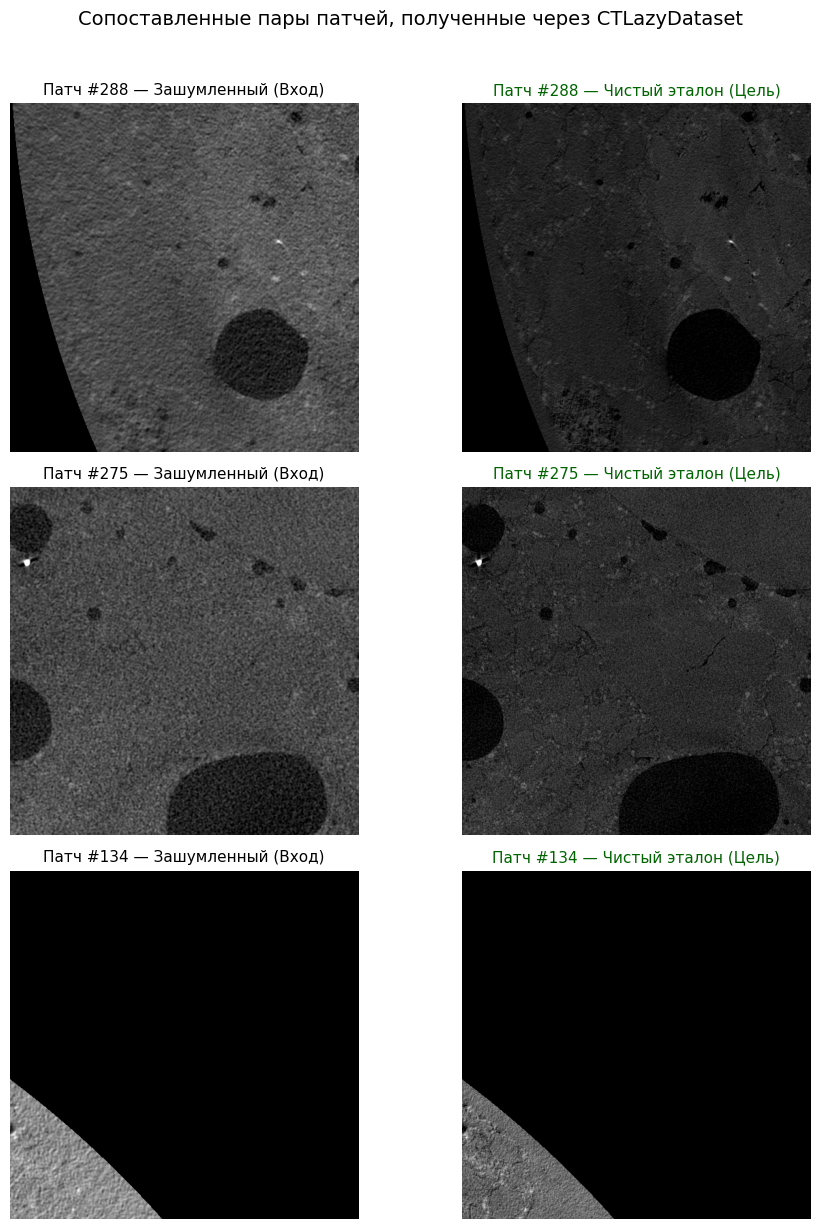

In [34]:
# --- 5. Отображение сопоставленных пар напрямую из CTLazyDataset ---
sample_indices = random.sample(range(len(dataset)), 3)

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for row, idx in enumerate(sample_indices):
    # Получаем тензоры через __getitem__ датасета (проверяем ленивую загрузку)
    noisy_tensor, clean_tensor = dataset[idx]

    # Переводим тензоры [1, 512, 512] в numpy [512, 512]
    noisy_p = noisy_tensor.squeeze().numpy()
    clean_p = clean_tensor.squeeze().numpy()

    # Левая колонка: Шумный вход
    axes[row, 0].imshow(noisy_p, cmap='gray')
    axes[row, 0].set_title(f"Патч #{idx} — Зашумленный (Вход)", fontsize=11)
    axes[row, 0].axis('off')

    # Правая колонка: Чистый эталон
    axes[row, 1].imshow(clean_p, cmap='gray')
    axes[row, 1].set_title(f"Патч #{idx} — Чистый эталон (Цель)", fontsize=11, color='darkgreen')
    axes[row, 1].axis('off')

plt.suptitle("Сопоставленные пары патчей, полученные через CTLazyDataset", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# МОДУЛЬ 1: Чистая функция нарезки (Slicer)

In [3]:
def slice_image_to_patches(image_or_path, patch_size=512, overlap_ratio=0.2):
    """
    ОТВЕТСТВЕННОСТЬ: Только геометрическая нарезка снимка.
    Возвращает:
      - patches: numpy массив (N, patch_size, patch_size)
      - coords: список координат (y, x)
      - orig_shape: размеры (H, W)
    """
    if isinstance(image_or_path, str):
        img = tiff.imread(image_or_path).astype(np.float32)
    else:
        img = image_or_path.astype(np.float32)

    h, w = img.shape
    stride = int(patch_size * (1.0 - overlap_ratio))

    y_steps = list(range(0, h - patch_size + 1, stride))
    if y_steps[-1] != h - patch_size: y_steps.append(h - patch_size)

    x_steps = list(range(0, w - patch_size + 1, stride))
    if x_steps[-1] != w - patch_size: x_steps.append(w - patch_size)

    patches = []
    coords = []
    for y in y_steps:
        for x in x_steps:
            patches.append(img[y:y+patch_size, x:x+patch_size])
            coords.append((y, x))

    return np.array(patches), coords, (h, w)

print("✅ Модуль 1 (Нарезка) готов!")

✅ Модуль 1 (Нарезка) готов!


# МОДУЛЬ 2: Независимые функции аугментации (Transforms)

In [4]:
import random
import torch
import numpy as np
import torchvision.transforms.functional as TF

# --- 1. D4 + Random Crop (работает с каждым отдельным патчем) ---
def d4_crop_ct_augmentation(noisy_tensor, clean_tensor, crop_size=256):
    # А. Random Crop (вырезаем 256x256)
    _, h, w = noisy_tensor.shape
    if h > crop_size and w > crop_size:
        top = random.randint(0, h - crop_size)
        left = random.randint(0, w - crop_size)
        noisy_tensor = noisy_tensor[:, top:top+crop_size, left:left+crop_size]
        clean_tensor = clean_tensor[:, top:top+crop_size, left:left+crop_size]

    # Б. Отражения (Flips)
    if random.random() > 0.5:
        noisy_tensor = TF.hflip(noisy_tensor)
        clean_tensor = TF.hflip(clean_tensor)
    if random.random() > 0.5:
        noisy_tensor = TF.vflip(noisy_tensor)
        clean_tensor = TF.vflip(clean_tensor)

    # В. Повороты на 90 градусов
    k = random.randint(0, 3)
    if k > 0:
        noisy_tensor = torch.rot90(noisy_tensor, k, dims=[1, 2])
        clean_tensor = torch.rot90(clean_tensor, k, dims=[1, 2])

    return noisy_tensor, clean_tensor


# --- 2. Paired MixUp + CutMix (работает с целым батчем) ---
def paired_batch_augmentation(noisy_batch, clean_batch, p_mixup=0.3, p_cutmix=0.3):
    r = random.random()
    if r < p_mixup:  # MixUp
        lam = np.random.beta(0.4, 0.4)
        perm = torch.randperm(noisy_batch.size(0))
        return lam * noisy_batch + (1 - lam) * noisy_batch[perm], lam * clean_batch + (1 - lam) * clean_batch[perm]
    elif r < p_mixup + p_cutmix:  # CutMix
        perm = torch.randperm(noisy_batch.size(0))
        B, C, H, W = noisy_batch.shape
        cut_h, cut_w = random.randint(H // 4, H // 2), random.randint(W // 4, W // 2)
        top, left = random.randint(0, H - cut_h), random.randint(0, W - cut_w)
        noisy_batch, clean_batch = noisy_batch.clone(), clean_batch.clone()
        noisy_batch[:, :, top:top+cut_h, left:left+cut_w] = noisy_batch[perm, :, top:top+cut_h, left:left+cut_w]
        clean_batch[:, :, top:top+cut_h, left:left+cut_w] = clean_batch[perm, :, top:top+cut_h, left:left+cut_w]
        return noisy_batch, clean_batch
    return noisy_batch, clean_batch

# МОДУЛЬ 3: Оркестратор датасета (CTModularDataset)


In [8]:
import os
import re
import numpy as np
import tifffile as tiff
import torch
from torch.utils.data import Dataset, DataLoader

# 1. Функция извлечения номера файла
def get_file_number(filename):
    """Извлекает числовой номер из имени файла (например, 'rec_00440.tif' -> 440)"""
    nums = re.findall(r'\d+', filename)
    return int(nums[-1]) if nums else -1


# class CTModularDataset(Dataset):
#     def __init__(
#         self, 
#         noisy_dir, 
#         clean_dir, 
#         patch_size=512, 
#         overlap_ratio=0.2, 
#         num_images=None,
#         transform_fn=None,
#         # 🔥 Диапазоны для исключения краевых срезов:
#         exclude_ranges=[(0, 400), (2430, 2816)] 
#     ):
#         self.patch_size = patch_size
#         self.transform_fn = transform_fn
        
#         # 1. Поиск всех пар файлов
#         noisy_files = sorted([f for f in os.listdir(noisy_dir) if f.lower().endswith(('.tif', '.tiff'))])
#         clean_files = sorted([f for f in os.listdir(clean_dir) if f.lower().endswith(('.tif', '.tiff'))])
#         all_pairs = sorted(list(set(noisy_files) & set(clean_files)))
        
#         # ======================================================================
#         # 🔥 ВОТ СЮДА ВСТАВЛЕН ФИЛЬТР СРЕЗОВ: Исключаем [0..400] и [2430..2816]
#         # ======================================================================
#         filtered_pairs = []
#         for f in all_pairs:
#             f_num = get_file_number(f)
#             # Проверяем, попадает ли номер в запрещенные диапазоны
#             is_excluded = any(start <= f_num <= end for start, end in exclude_ranges)
#             if not is_excluded:
#                 filtered_pairs.append(f)

#         # Применяем ограничение num_images (если задано)
#         if num_images is not None:
#             self.common_names = filtered_pairs[:num_images]
#         else:
#             self.common_names = filtered_pairs

#         self.noisy_paths = [os.path.join(noisy_dir, f) for f in self.common_names]
#         self.clean_paths = [os.path.join(clean_dir, f) for f in self.common_names]

#         # 2. Построение координатной сетки
#         _, self.base_coords, _ = slice_image_to_patches(self.noisy_paths[0], patch_size, overlap_ratio)

#         self.patch_index = []
#         for img_idx in range(len(self.common_names)):
#             for y, x in self.base_coords:
#                 self.patch_index.append((img_idx, y, x))

#         # Кэш для ускорения чтения
#         self._cache = {}
#         self._current_file_idx = -1

#         print(f"📁 Всего файлов до фильтрации: {len(all_pairs)} пар")
#         print(f"✅ В работу взято после фильтрации: {len(self.common_names)} пар снимков (от {self.common_names[0]} до {self.common_names[-1]})")
#         print(f"🎉 Сформирован индекс: {len(self.patch_index)} патчей {patch_size}x{patch_size}")
#         print(f"🔄 Стратегия аугментации: {transform_fn.__name__ if transform_fn else 'Без аугментации'}\n")

#     def __len__(self):
#         return len(self.patch_index)

#     def __getitem__(self, idx):
#         img_idx, y, x = self.patch_index[idx]

#         # Если файл сменился — загружаем новый
#         if img_idx != self._current_file_idx:
#             self._load_and_cache_file(img_idx)
#             self._current_file_idx = img_idx

#         # Берем патч из кэша
#         n_patch, c_patch = self._cache[(y, x)]

#         # Нормализация [0, 1]
#         n_patch = (n_patch - np.min(n_patch)) / (np.max(n_patch) - np.min(n_patch) + 1e-8)
#         c_patch = (c_patch - np.min(c_patch)) / (np.max(c_patch) - np.min(c_patch) + 1e-8)

#         n_tensor = torch.from_numpy(n_patch).unsqueeze(0).float()
#         c_tensor = torch.from_numpy(c_patch).unsqueeze(0).float()

#         if self.transform_fn is not None:
#             n_tensor, c_tensor = self.transform_fn(n_tensor, c_tensor)

#         return n_tensor, c_tensor

class CTModularDataset(Dataset):
    def __init__(
        self, 
        noisy_dir, 
        clean_dir, 
        file_list=None,        # 🔥 ПЕРЕДАЕМ ГОТОВЫЙ СПИСОК (train_files или val_files)
        patch_size=512, 
        overlap_ratio=0.2, 
        transform_fn=None
    ):
        self.patch_size = patch_size
        self.transform_fn = transform_fn
        
        # Если список файлов передан напрямую (train или val) — берем его
        if file_list is not None:
            self.common_names = file_list
        else:
            noisy_files = sorted([f for f in os.listdir(noisy_dir) if f.lower().endswith(('.tif', '.tiff'))])
            clean_files = sorted([f for f in os.listdir(clean_dir) if f.lower().endswith(('.tif', '.tiff'))])
            self.common_names = sorted(list(set(noisy_files) & set(clean_files)))

        self.noisy_paths = [os.path.join(noisy_dir, f) for f in self.common_names]
        self.clean_paths = [os.path.join(clean_dir, f) for f in self.common_names]

        # 2. Построение координатной сетки
        _, self.base_coords, _ = slice_image_to_patches(self.noisy_paths[0], patch_size, overlap_ratio)

        # 3. Строим точный индекс только для переданных файлов
        self.patch_index = [
            (img_idx, y, x) 
            for img_idx in range(len(self.common_names)) 
            for y, x in self.base_coords
        ]

        print(f"📁 Загружено пар снимков: {len(self.common_names)} (от {self.common_names[0]} до {self.common_names[-1]})")
        print(f"🎉 Сформирован индекс: {len(self.patch_index)} патчей {patch_size}x{patch_size}")
        print(f"🔄 Стратегия аугментации: {transform_fn.__name__ if transform_fn else 'Без аугментации'}\n")

    def __len__(self):
        return len(self.patch_index)

    def __getitem__(self, idx):
        img_idx, y, x = self.patch_index[idx]
        p = self.patch_size

        n_img = tiff.imread(self.noisy_paths[img_idx]).astype(np.float32)
        c_img = tiff.imread(self.clean_paths[img_idx]).astype(np.float32)

        n_patch = n_img[y:y+p, x:x+p]
        c_patch = c_img[y:y+p, x:x+p]

        # Нормализация [0, 1]
        n_patch = (n_patch - np.min(n_patch)) / (np.max(n_patch) - np.min(n_patch) + 1e-8)
        c_patch = (c_patch - np.min(c_patch)) / (np.max(c_patch) - np.min(c_patch) + 1e-8)

        n_tensor = torch.from_numpy(n_patch).unsqueeze(0).float()
        c_tensor = torch.from_numpy(c_patch).unsqueeze(0).float()

        if self.transform_fn is not None:
            n_tensor, c_tensor = self.transform_fn(n_tensor, c_tensor)

        return n_tensor, c_tensor

    def _load_and_cache_file(self, img_idx):
        """Загружает весь файл, нарезает все патчи и сохраняет в self._cache"""
        noisy_path = self.noisy_paths[img_idx]
        clean_path = self.clean_paths[img_idx]

        n_img = tiff.imread(noisy_path).astype(np.float32)
        c_img = tiff.imread(clean_path).astype(np.float32)

        p = self.patch_size
        cache = {}
        for y, x in self.base_coords:
            n_patch = n_img[y:y+p, x:x+p]
            c_patch = c_img[y:y+p, x:x+p]
            cache[(y, x)] = (n_patch, c_patch)

        self._cache = cache

In [5]:
# from torch.utils.data import Dataset, DataLoader

# class CTModularDataset(Dataset):
#     def __init__(
#         self, 
#         noisy_dir, 
#         clean_dir, 
#         patch_size=512, 
#         overlap_ratio=0.2, 
#         num_images=None,
#         transform_fn=None
#     ):
#         self.patch_size = patch_size
#         self.transform_fn = transform_fn
        
#         noisy_files = sorted([f for f in os.listdir(noisy_dir) if f.lower().endswith(('.tif', '.tiff'))])
#         clean_files = sorted([f for f in os.listdir(clean_dir) if f.lower().endswith(('.tif', '.tiff'))])
#         common = sorted(list(set(noisy_files) & set(clean_files)))
        
#         if num_images is not None:
#             self.common_names = common[:num_images]
#         else:
#             self.common_names = common

#         self.noisy_paths = [os.path.join(noisy_dir, f) for f in self.common_names]
#         self.clean_paths = [os.path.join(clean_dir, f) for f in self.common_names]

#         _, self.base_coords, _ = slice_image_to_patches(self.noisy_paths[0], patch_size, overlap_ratio)

#         self.patch_index = []
#         for img_idx in range(len(self.common_names)):
#             for y, x in self.base_coords:
#                 self.patch_index.append((img_idx, y, x))

#         print(f"📁 Загружено пар снимков: {len(self.common_names)}")
#         print(f"🎉 Сформирован индекс: {len(self.patch_index)} патчей {patch_size}x{patch_size}")
#         print(f"🔄 Подключенная стратегия аугментации: {transform_fn.__name__ if transform_fn else 'Без аугментации'}\n")

#     def __len__(self):
#         return len(self.patch_index)

#     def __getitem__(self, idx):
#         img_idx, y, x = self.patch_index[idx]
#         p = self.patch_size

#         n_img = tiff.imread(self.noisy_paths[img_idx]).astype(np.float32)
#         c_img = tiff.imread(self.clean_paths[img_idx]).astype(np.float32)

#         n_patch = n_img[y:y+p, x:x+p]
#         c_patch = c_img[y:y+p, x:x+p]

#         n_patch = (n_patch - np.min(n_patch)) / (np.max(n_patch) - np.min(n_patch) + 1e-8)
#         c_patch = (c_patch - np.min(c_patch)) / (np.max(c_patch) - np.min(c_patch) + 1e-8)

#         n_tensor = torch.from_numpy(n_patch).unsqueeze(0).float()
#         c_tensor = torch.from_numpy(c_patch).unsqueeze(0).float()

#         # 🔥 ЗДЕСЬ ПРИМЕНЯЕТСЯ D4 + RANDOM CROP:
#         if self.transform_fn is not None:
#             n_tensor, c_tensor = self.transform_fn(n_tensor, c_tensor)

#         return n_tensor, c_tensor

# print("✅ Модуль 3 (Датасет) готов!")

# Инициализация


In [10]:
# ==============================================================================
# ⚙️ РАЗДЕЛЕНИЕ НА TRAIN И VAL
# ==============================================================================
import re

NOISY_DIR = "filestore/filestorage/V_beton30_angle05"
CLEAN_DIR = "filestore/filestorage/V_beton30_angle005"

def get_file_number(filename):
    nums = re.findall(r'\d+', filename)
    return int(nums[-1]) if nums else -1

# 1. Поиск всех пар файлов
noisy_files = sorted([f for f in os.listdir(NOISY_DIR) if f.lower().endswith(('.tif', '.tiff'))])
clean_files = sorted([f for f in os.listdir(CLEAN_DIR) if f.lower().endswith(('.tif', '.tiff'))])
all_pairs = sorted(list(set(noisy_files) & set(clean_files)))

# 2. Фильтруем краевые срезы (исключаем [0..400] и [2430..2816])
filtered_pairs = [
    f for f in all_pairs 
    if not (0 <= get_file_number(f) <= 399 or 2430 <= get_file_number(f) <= 2816)
]

print(f"📁 Всего файлов до фильтрации: {len(all_pairs)} пар")
print(f"✅ Полезных файлов после фильтрации: {len(filtered_pairs)} пар\n")

# 3. ДЕЛИМ 2029 ФАЙЛОВ: 80% на Train, 20% на Val
train_split = int(0.8 * len(filtered_pairs))  # 1623 файла
train_files = filtered_pairs[:train_split]     # от 401 до 2023
val_files = filtered_pairs[train_split:]       # от 2024 до 2429

print(f"📊 РАСПРЕДЕЛЕНИЕ ДАТАСЕТА:")
print(f"   └── Обучающая выборка (Train 80%): {len(train_files)} пар (от {train_files[0]} до {train_files[-1]})")
print(f"   └── Валидация (Val/Test 20%):      {len(val_files)} пар (от {val_files[0]} до {val_files[-1]})\n")

# 4. Создаем ОБУЧАЮЩИЙ датасет (передаем file_list=train_files)
train_dataset = CTModularDataset(
    noisy_dir=NOISY_DIR,
    clean_dir=CLEAN_DIR,
    file_list=train_files,  # 🔥 ровно 1623 файла
    patch_size=512,
    overlap_ratio=0.2,
    transform_fn=d4_crop_ct_augmentation
)

# 5. Создаем ВАЛИДАЦИОННЫЙ датасет (передаем file_list=val_files)
val_dataset = CTModularDataset(
    noisy_dir=NOISY_DIR,
    clean_dir=CLEAN_DIR,
    file_list=val_files,    # 🔥 ровно 406 файлов
    patch_size=512,
    overlap_ratio=0.2,
    transform_fn=None
)

# 6. DataLoader'ы
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

print(f"🎉 ИТОГ: Train = {len(train_dataset)} патчей | Val = {len(val_dataset)} патчей (0% пересечения)")

📁 Всего файлов до фильтрации: 2816 пар
✅ Полезных файлов после фильтрации: 2030 пар

📊 РАСПРЕДЕЛЕНИЕ ДАТАСЕТА:
   └── Обучающая выборка (Train 80%): 1624 пар (от rec_00400.tif до rec_02023.tif)
   └── Валидация (Val/Test 20%):      406 пар (от rec_02024.tif до rec_02429.tif)

📁 Загружено пар снимков: 1624 (от rec_00400.tif до rec_02023.tif)
🎉 Сформирован индекс: 103936 патчей 512x512
🔄 Стратегия аугментации: d4_crop_ct_augmentation

📁 Загружено пар снимков: 406 (от rec_02024.tif до rec_02429.tif)
🎉 Сформирован индекс: 25984 патчей 512x512
🔄 Стратегия аугментации: Без аугментации

🎉 ИТОГ: Train = 103936 патчей | Val = 25984 патчей (0% пересечения)


In [7]:
# import matplotlib.pyplot as plt

# # ==============================================================================
# # 1. РАСЧЕТ И ВЫВОД КОЛИЧЕСТВА ДАННЫХ
# # ==============================================================================
# base_patches_count = len(dataset_d4)

# # D4-группа симметрий: 4 поворота (0°, 90°, 180°, 270°) * 2 отражения = 8 вариантов
# d4_multiplier = 8  
# effective_dataset_size = base_patches_count * d4_multiplier

# print("=" * 65)
# print("📊 СТАТИСТИКА ДАТАСЕТА И АУГМЕНТАЦИИ:")
# print(f"• Исходных снимков в обработке:          {len(dataset_d4.common_names)} пар")
# print(f"• Базовое количество патчей (без аугм.): {base_patches_count:,} шт.")
# print(f"• Коэффициент разнообразия (D4 Group):   x{d4_multiplier} (4 угла × 2 флипа)")
# print(f"• ЭФФЕКТИВНЫЙ ОБЪЕМ ДАННЫХ ДЛЯ ОБУЧЕНИЯ: {effective_dataset_size:,} уникальных пар!")
# print("=" * 65)
# print("💡 Пояснение: В оперативной памяти хранится всего 20 МБ, но нейросеть")
# print(f"   за время обучения увидит {effective_dataset_size:,} разных пространственных состояний.\n")

# # ==============================================================================
# # 2. ВИЗУАЛИЗАЦИЯ: 3 СЛУЧАЙНЫЕ АУГМЕНТАЦИИ ОДНОГО И ТОГО ЖЕ ПАТЧА
# # ==============================================================================
# # Выбираем информативный патч из середины образца
# SAMPLE_IDX = len(dataset_d4) // 2

# fig, axes = plt.subplots(3, 2, figsize=(10, 13))

# for row in range(3):
#     # При каждом обращении dataset_d4[SAMPLE_IDX] на лету генерирует новую трансформацию!
#     noisy_tensor, clean_tensor = dataset_d4[SAMPLE_IDX]
    
#     noisy_img = noisy_tensor.squeeze().numpy()
#     clean_img = clean_tensor.squeeze().numpy()

#     # Левая колонка: Шумный
#     axes[row, 0].imshow(noisy_img, cmap='gray')
#     axes[row, 0].set_title(f"Вариация #{row+1} — Зашумленный (Вход)", fontsize=11)
#     axes[row, 0].axis('off')

#     # Правая колонка: Чистый эталон
#     axes[row, 1].imshow(clean_img, cmap='gray')
#     axes[row, 1].set_title(f"Вариация #{row+1} — Чистый эталон (Цель)", fontsize=11, color='darkgreen')
#     axes[row, 1].axis('off')

# plt.suptitle(f"Примеры аугментаций для патча #{SAMPLE_IDX} (Сгенерировано 'на лету')", fontsize=13, y=1.02)
# plt.tight_layout()
# plt.show()

# U-Net с Global Residual Connection

In [8]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    """(Conv2d 3x3 -> ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNetDenoising(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Энкодер (сжатие)
        current_in = in_channels
        for feature in features:
            self.downs.append(DoubleConv(current_in, feature))
            current_in = feature

        # Горлышко
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Декодер (восстановление)
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature * 2, feature))

        # Выходной слой предсказания шума
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        original_input = x  # Входной зашумленный снимок
        skip_connections = []

        # Проход вниз
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        # Проход вверх + Skip Connections
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip_conn = skip_connections[i // 2]
            x = self.ups[i + 1](torch.cat((skip_conn, x), dim=1))

        # Прогноз шума
        predicted_noise = self.final_conv(x)

        # 🔥 GLOBAL RESIDUAL CONNECTION:
        # Чистый патч = Входной патч МИНУС Предсказанный шум
        cleaned_patch = original_input - predicted_noise
        return cleaned_patch


# Инициализируем модель и отправляем на доступное устройство
model = UNetDenoising(in_channels=1, out_channels=1).to(device)
print(f"✅ U-Net инициализирован. Параметров: {sum(p.numel() for p in model.parameters()):,}")

✅ U-Net инициализирован. Параметров: 31,024,705


# loss function 

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CharbonnierLoss(nn.Module):
    def __init__(self, eps=1e-3):
        super().__init__()
        self.eps2 = eps ** 2

    def forward(self, pred, target):
        return torch.mean(torch.sqrt((pred - target)**2 + self.eps2))


class EdgeLoss(nn.Module):
    """Градиенты Собеля по X и Y (штраф за смазанные края)"""
    def __init__(self):
        super().__init__()
        sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        self.register_buffer('sobel_x', sobel_x)
        self.register_buffer('sobel_y', sobel_y)

    def forward(self, pred, target):
        pred_x = F.conv2d(pred, self.sobel_x.to(pred.device), padding=1)
        pred_y = F.conv2d(pred, self.sobel_y.to(pred.device), padding=1)
        target_x = F.conv2d(target, self.sobel_x.to(pred.device), padding=1)
        target_y = F.conv2d(target, self.sobel_y.to(pred.device), padding=1)
        return F.l1_loss(pred_x, target_x) + F.l1_loss(pred_y, target_y)


class FocalFrequencyLoss(nn.Module):
    """Частотная ошибка Фурье 2D"""
    def __init__(self, alpha=1.0):
        super().__init__()
        self.alpha = alpha

    def forward(self, pred, target):
        pred_fft = torch.fft.rfft2(pred, norm='ortho')
        target_fft = torch.fft.rfft2(target, norm='ortho')
        diff_sq = (pred_fft.real - target_fft.real)**2 + (pred_fft.imag - target_fft.imag)**2
        weight = diff_sq ** self.alpha
        weight = weight / (weight.mean() + 1e-8)
        return torch.mean(weight * diff_sq)


class FullHybridCTLoss(nn.Module):
    """
    Полный 3-уровневый лосс: Пространство (Charbonnier) + Градиенты (Edge) + Частоты (FFT)
    """
    def __init__(self, w_charb=1.0, w_edge=0.2, w_fft=0.3):
        super().__init__()
        self.w_charb = w_charb
        self.w_edge = w_edge
        self.w_fft = w_fft

        self.charb = CharbonnierLoss()
        self.edge = EdgeLoss()
        self.fft = FocalFrequencyLoss()

    def forward(self, pred, target):
        l_charb = self.charb(pred, target)
        l_edge = self.edge(pred, target)
        l_fft = self.fft(pred, target)

        return (self.w_charb * l_charb) + (self.w_edge * l_edge) + (self.w_fft * l_fft)

# Цикл обучения (Training Loop)

In [ ]:
import os
import time
import torch.optim as optim
from tqdm.auto import tqdm

criterion = FullHybridCTLoss(w_charb=1.0, w_edge=0.2, w_fft=0.3)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

NUM_EPOCHS = 1000
use_amp = (device.type == 'cuda')
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

best_val_loss = float('inf')  # Отслеживаем лучший результат на ВАЛИДАЦИИ
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "unet_best_model.pth")
LAST_CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "unet_last_checkpoint.pth")

print("=" * 80)
print(f"🚀 ЗАПУСК ОБУЧЕНИЯ С ВАЛИДАЦИЕЙ (Train: {len(train_dataset)} патчей, Val: {len(val_dataset)} патчей)")
print("=" * 80 + "\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # --------------------------------------------------------------------------
    # 1. ФАЗА ОБУЧЕНИЯ (TRAIN)
    # --------------------------------------------------------------------------
    model.train()
    train_running_loss = 0.0
    train_loop = tqdm(train_loader, desc=f"Эпоха [{epoch+1:02d}/{NUM_EPOCHS:02d}] TRAIN", unit="батч")

    for noisy_b, clean_b in train_loop:
        noisy_b = noisy_b.to(device, non_blocking=True)
        clean_b = clean_b.to(device, non_blocking=True)
        
        # 🔥 ДОБАВИТЬ ВОТ ЭТУ ОДНУ СТРОЧКУ (применяет MixUp / CutMix на обучении):
        noisy_b, clean_b = paired_batch_augmentation(noisy_b, clean_b, p_mixup=0.3, p_cutmix=0.3)


        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            preds = model(noisy_b)
            loss = criterion(preds, clean_b)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_running_loss += loss.item()
        train_loop.set_postfix(train_loss=f"{loss.item():.4f}")

    train_loss = train_running_loss / len(train_loader)

    # --------------------------------------------------------------------------
    # 2. ФАЗА ВАЛИДАЦИИ (VAL / TEST) - БЕЗ расчета градиентов
    # --------------------------------------------------------------------------
    model.eval()
    val_running_loss = 0.0

    with torch.no_grad():
        for noisy_b, clean_b in val_loader:
            noisy_b = noisy_b.to(device, non_blocking=True)
            clean_b = clean_b.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                preds = model(noisy_b)
                loss = criterion(preds, clean_b)

            val_running_loss += loss.item()

    val_loss = val_running_loss / len(val_loader)
    epoch_time = time.time() - start_time

    print(f"⏱️ Эпоха {epoch+1:02d} ({epoch_time:.1f}с) | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}")

    # --------------------------------------------------------------------------
    # 3. СОХРАНЕНИЕ ЛУЧШЕЙ МОДЕЛИ ПО VAL LOSS
    # --------------------------------------------------------------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"   ⭐ [НОВЫЙ РЕКОРД НА VAL] Val Loss = {best_val_loss:.5f} -> Сохранено в '{BEST_MODEL_PATH}'")

    # Сохраняем полный чекпоинт
    checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'best_val_loss': best_val_loss
    }
    torch.save(checkpoint, LAST_CHECKPOINT_PATH)

print("\n" + "=" * 80)
print(f"🎉 ОБУЧЕНИЕ ЗАВЕРШЕНО! Лучший результат на незнакомых снимках (Val Loss): {best_val_loss:.5f}")
print("=" * 80)

Эпоха [02/1000] TRAIN:  61%|██████    | 918/1502 [1:48:16<26:36,  2.73s/батч, train_loss=2.3028]  

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

# 1. Загружаем лучшую сохраненную модель
BEST_MODEL_PATH = "checkpoints/unet_best_model.pth"

# Переводим модель в режим оценки (Inference / Eval)
if os.path.exists(BEST_MODEL_PATH):
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    print(f"✅ Успешно загружены веса лучшей модели из: '{BEST_MODEL_PATH}'")
else:
    print("⚠️ Файл чекпоинта не найден, используем модель из оперативной памяти.")

model.eval()

# 2. Функции расчета математических метрик качества
def calculate_psnr(pred, target):
    """Пиковое отношение сигнал/шум (в dB). Чем выше, тем лучше."""
    mse = np.mean((pred - target) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(1.0 / np.sqrt(mse))

def calculate_ssim(img1, img2):
    """Упрощенный расчет структурного сходства SSIM (от 0 до 1)."""
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2
    mu1 = img1.mean()
    mu2 = img2.mean()
    sigma1 = np.var(img1)
    sigma2 = np.var(img2)
    sigma12 = np.mean((img1 - mu1) * (img2 - mu2))
    ssim = ((2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)) / ((mu1**2 + mu2**2 + C1) * (sigma1 + sigma2 + C2))
    return ssim

# 3. Ищем 3 информативных патча (где есть структура бетона, а не сплошная чернота)
selected_indices = []
for idx in range(len(dataset_d4)):
    # Берем патч без аугментаций для объективного теста
    n_t, c_t = dataset_d4.patch_index[idx], dataset_d4.patch_index[idx]
    sample_clean = tiff.imread(dataset_d4.clean_paths[n_t[0]])[n_t[1]:n_t[1]+512, n_t[2]:n_t[2]+512]
    
    # Если на снимке есть детали (разброс яркости > порога)
    if np.std(sample_clean) > 0.04:
        selected_indices.append(idx)
        if len(selected_indices) == 3:
            break

if len(selected_indices) < 3:
    selected_indices = [0, len(dataset_d4) // 2, len(dataset_d4) - 1]

# 4. Отрисовка 4-колоночного сравнения
fig, axes = plt.subplots(3, 4, figsize=(18, 14))

psnr_noisy_list, psnr_pred_list = [], []
ssim_noisy_list, ssim_pred_list = [], []

for row, idx in enumerate(selected_indices):
    # Получаем исходные тензоры
    noisy_tensor, clean_tensor = dataset_d4[idx]

    # Инференс U-Net
    with torch.no_grad():
        input_b = noisy_tensor.unsqueeze(0).to(device)
        pred_tensor = model(input_b)

    # Перевод в numpy массивы
    noisy_np = noisy_tensor.squeeze().cpu().numpy()
    pred_np = pred_tensor.squeeze().cpu().numpy()
    clean_np = clean_tensor.squeeze().cpu().numpy()

    # Клиппинг значений в [0, 1] на случай микровылетов
    pred_np = np.clip(pred_np, 0.0, 1.0)

    # Карта удаленного шума
    noise_extracted = noisy_np - pred_np

    # Метрики
    psnr_noisy = calculate_psnr(noisy_np, clean_np)
    psnr_pred = calculate_psnr(pred_np, clean_np)
    ssim_noisy = calculate_ssim(noisy_np, clean_np)
    ssim_pred = calculate_ssim(pred_np, clean_np)

    psnr_noisy_list.append(psnr_noisy)
    psnr_pred_list.append(psnr_pred)
    ssim_noisy_list.append(ssim_noisy)
    ssim_pred_list.append(ssim_pred)

    # Колонка 1: Шумный вход
    axes[row, 0].imshow(noisy_np, cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title(f"1. Шумный вход (Noisy)\nPSNR: {psnr_noisy:.2f} dB | SSIM: {ssim_noisy:.3f}", fontsize=10)
    axes[row, 0].axis('off')

    # Колонка 2: Предсказание U-Net
    axes[row, 1].imshow(pred_np, cmap='gray', vmin=0, vmax=1)
    axes[row, 1].set_title(f"2. Выход U-Net (Cleaned)\nPSNR: {psnr_pred:.2f} dB | SSIM: {ssim_pred:.3f}", fontsize=10, color='darkgreen')
    axes[row, 1].axis('off')

    # Колонка 3: Эталон
    axes[row, 2].imshow(clean_np, cmap='gray', vmin=0, vmax=1)
    axes[row, 2].set_title(f"3. Чистый эталон (Target)\nPSNR: ∞ | SSIM: 1.000", fontsize=10)
    axes[row, 2].axis('off')

    # Колонка 4: Извлеченный шум
    axes[row, 3].imshow(noise_extracted, cmap='coolwarm')
    axes[row, 3].set_title("4. Удаленный шум КТ\n(Вход минус Выход)", fontsize=10, color='darkblue')
    axes[row, 3].axis('off')

plt.suptitle("📊 ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ РАБОТЫ U-NET С GLOBAL RESIDUAL CONNECTION", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

# 5. Итоговый отчет по метрикам
print("=" * 65)
print("📈 ИТОГОВЫЙ ПРИРОСТ КАЧЕСТВА ПОСЛЕ ОБУЧЕНИЯ (Среднее по образцам):")
print(f"• Метрика PSNR:  было {np.mean(psnr_noisy_list):.2f} dB ──► стало {np.mean(psnr_pred_list):.2f} dB (Прирост: +{np.mean(psnr_pred_list) - np.mean(psnr_noisy_list):.2f} dB 🚀)")
print(f"• Метрика SSIM:  было {np.mean(ssim_noisy_list):.3f}    ──► стало {np.mean(ssim_pred_list):.3f}    (Прирост: +{np.mean(ssim_pred_list) - np.mean(ssim_noisy_list):.3f} 🚀)")
print("=" * 65)

# Функция визуализации всех 64 патчей для случайного тестового снимка

In [ ]:
import os
import random
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
import torch

def visualize_all_patches_for_random_test_image(
    model,
    val_dataset,
    patch_size=512,
    overlap_ratio=0.2,
    max_patches_to_show=None,  # None = вывести ВСЕ 64 патча (или укажите число, например 10)
    checkpoint_path="checkpoints/unet_best_model.pth",
    device=device
):
    """
    Выбирает случайный снимок из валидации, нарезает на 64 патча, 
    прогоняет через модель и выводит каждый патч:
    [1. Шумный вход | 2. Очищенный U-Net | 3. Чистый эталон]
    """
    # 1. Загружаем веса лучшей модели (если чекпоинт существует)
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        print(f"✅ Успешно загружены лучшие веса из: '{checkpoint_path}'")
    model.eval()

    # 2. Выбираем случайный снимок из валидационной выборки
    rand_idx = random.randint(0, len(val_dataset.common_names) - 1)
    test_noisy_path = val_dataset.noisy_paths[rand_idx]
    test_clean_path = val_dataset.clean_paths[rand_idx]
    file_name = val_dataset.common_names[rand_idx]

    print(f"🎯 Выбран случайный тестовый снимок: '{file_name}' (Индекс в выборке: {rand_idx})")

    # 3. Нарезка полного снимка через Модуль 1 (slice_image_to_patches)
    noisy_patches, coords, orig_shape = slice_image_to_patches(
        test_noisy_path, patch_size=patch_size, overlap_ratio=overlap_ratio
    )
    clean_patches, _, _ = slice_image_to_patches(
        test_clean_path, patch_size=patch_size, overlap_ratio=overlap_ratio
    )

    total_patches = len(noisy_patches)
    print(f"🧩 Нарезано патчей со снимка: {total_patches} шт. (сетка {int(np.sqrt(total_patches))}x{int(np.sqrt(total_patches))})")

    # 4. Прогон всех 64 патчей через U-Net батчами
    cleaned_patches = []
    batch_size = 8

    with torch.no_grad():
        for i in range(0, total_patches, batch_size):
            batch_n = noisy_patches[i:i+batch_size]

            # Нормализация каждого патча в [0, 1]
            batch_norm = []
            for p in batch_n:
                p_norm = (p - np.min(p)) / (np.max(p) - np.min(p) + 1e-8)
                batch_norm.append(p_norm)

            batch_tensor = torch.from_numpy(np.array(batch_norm)).unsqueeze(1).float().to(device)

            # Прямой проход U-Net (работает Global Residual Connection)
            preds = model(batch_tensor)
            preds_np = preds.squeeze(1).cpu().numpy()

            for p in preds_np:
                cleaned_patches.append(p)

    # 5. Отрисовка патчей
    num_to_plot = total_patches if max_patches_to_show is None else min(max_patches_to_show, total_patches)
    print(f"🖼️ Отрисовываем {num_to_plot} патчей в формате [Вход | Выход U-Net | Эталон]...\n")

    # Создаем большую фигуру: num_to_plot рядов, 3 колонки
    fig, axes = plt.subplots(num_to_plot, 3, figsize=(15, num_to_plot * 4))

    # Если вдруг выбран только 1 патч, приводим axes к 2D виду
    if num_to_plot == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(num_to_plot):
        n_p = noisy_patches[i]
        c_p = clean_patches[i]
        p_p = cleaned_patches[i]
        y, x = coords[i]

        # Нормализация для одинаковой и честной контрастности при показе
        n_disp = (n_p - np.min(n_p)) / (np.max(n_p) - np.min(n_p) + 1e-8)
        c_disp = (c_p - np.min(c_p)) / (np.max(c_p) - np.min(c_p) + 1e-8)
        p_disp = np.clip(p_p, 0.0, 1.0)

        # Колонка 1: Шумный оригинал
        axes[i, 0].imshow(n_disp, cmap='gray')
        axes[i, 0].set_title(f"Патч #{i} (y={y}, x={x})\n1. Зашумленный вход", fontsize=10)
        axes[i, 0].axis('off')

        # Колонка 2: Выход вашей U-Net
        axes[i, 1].imshow(p_disp, cmap='gray')
        axes[i, 1].set_title(f"Патч #{i} (y={y}, x={x})\n2. Очищенный U-Net (Предсказание)", fontsize=10, color='darkgreen')
        axes[i, 1].axis('off')

        # Колонка 3: Чистый эталон
        axes[i, 2].imshow(c_disp, cmap='gray')
        axes[i, 2].set_title(f"Патч #{i} (y={y}, x={x})\n3. Чистый эталон (Target)", fontsize=10)
        axes[i, 2].axis('off')

    plt.suptitle(f"Сравнение всех {num_to_plot} патчей для снимка '{file_name}'", fontsize=15, y=1.001)
    plt.tight_layout()
    plt.show()

print("✅ Функция визуализации всех патчей готова к запуску!")

✅ Успешно загружены лучшие веса из: 'checkpoints/unet_best_model.pth'
🎯 Выбран случайный тестовый снимок: 'rec_00008.tif' (Индекс в выборке: 0)
🧩 Нарезано патчей со снимка: 64 шт. (сетка 8x8)
🖼️ Отрисовываем 10 патчей в формате [Вход | Выход U-Net | Эталон]...



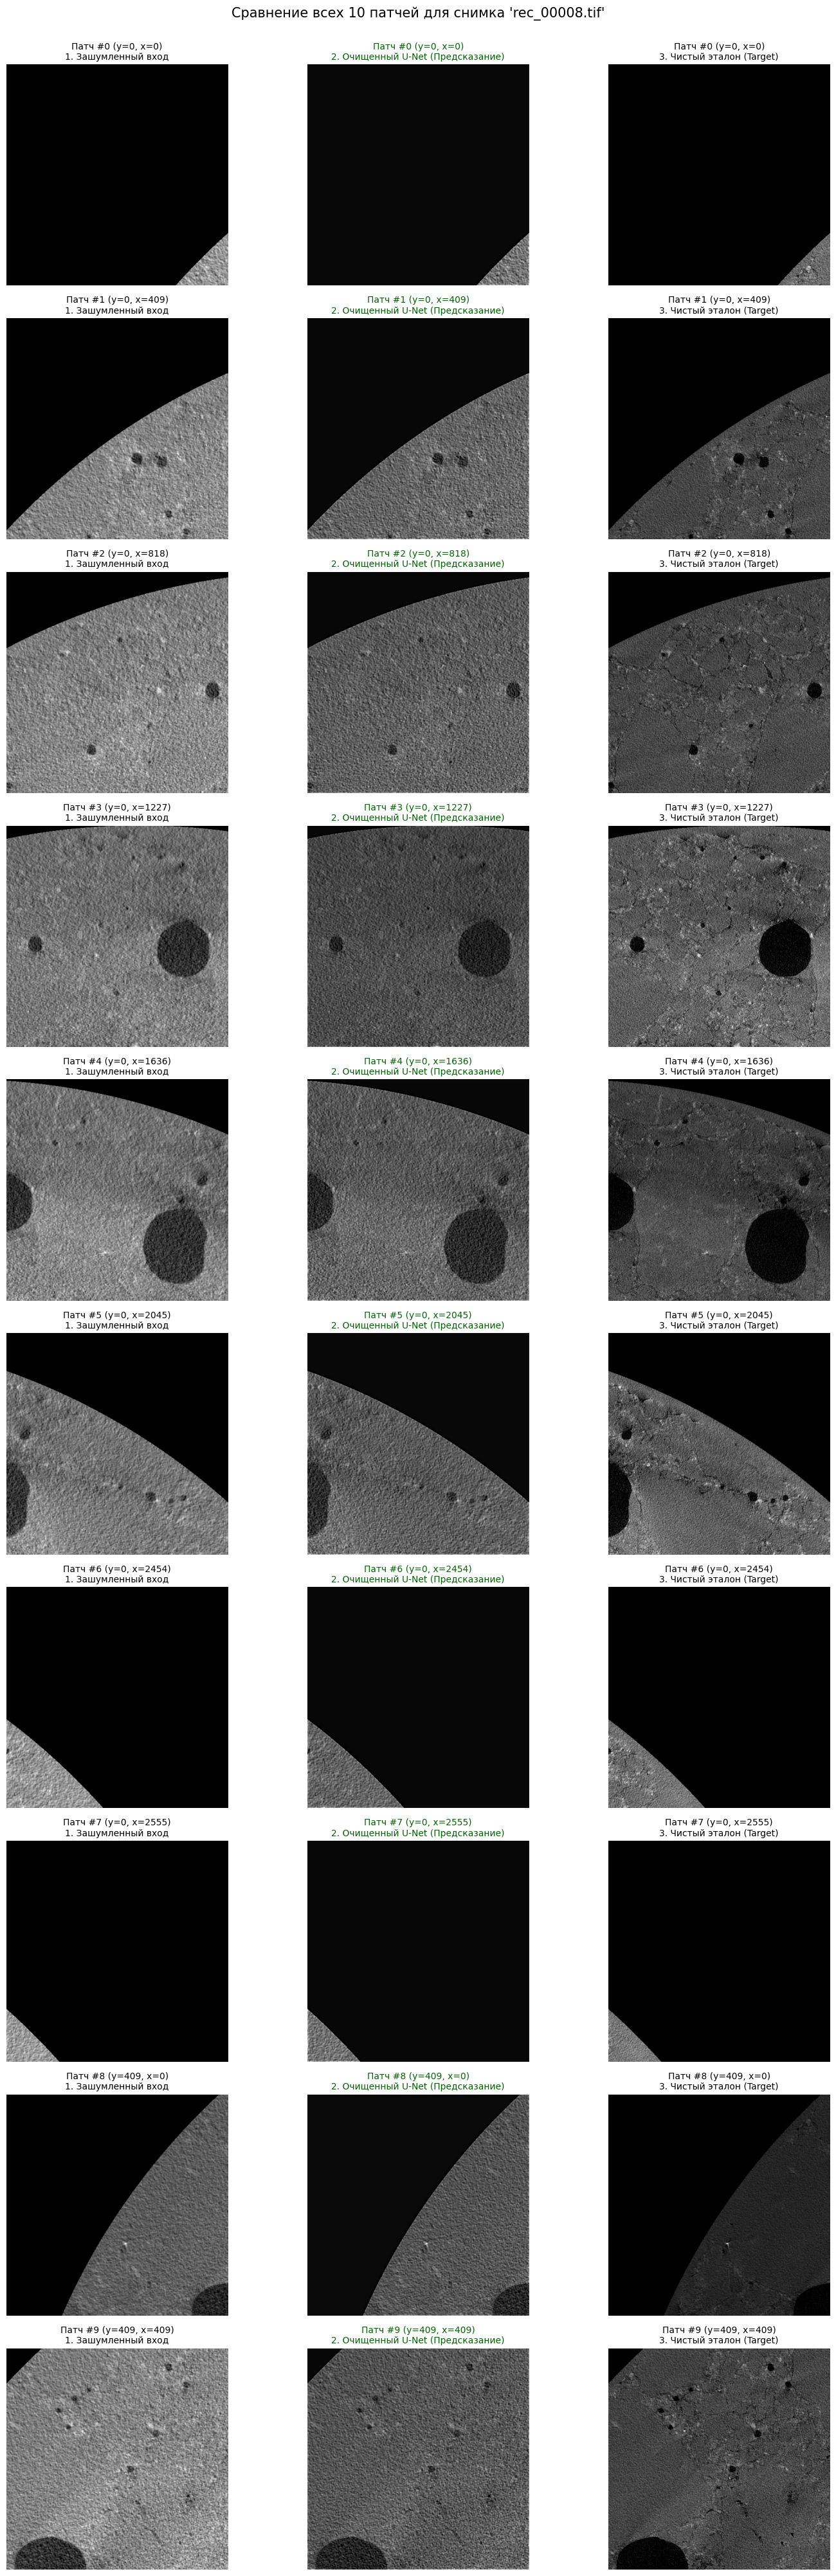

In [14]:
# Запуск для вывода ВСЕХ 64 патчей случайного снимка из val_dataset:
visualize_all_patches_for_random_test_image(
    model=model,
    val_dataset=val_dataset,
    patch_size=512,
    overlap_ratio=0.2,
    max_patches_to_show=10,  # <--- None выведет все 64 патча подряд
    checkpoint_path="checkpoints/unet_best_model.pth",
    device=device
)